In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
import pandas as pd
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms 

from sklearn.metrics import f1_score

from training_monitor import TrainingMonitor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import albumentations as A
from albumentations.pytorch import ToTensorV2
import ast

from functools import lru_cache
from tqdm.auto import tqdm

<jemalloc>: Unsupported system page size


In [2]:
import torch, gc, random
import numpy as np

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
train1_path = "/datasets/multi-view-pig-posture-recognition/train1_images"
train2_path = "/datasets/multi-view-pig-posture-recognition/train2_images"
test_path   = "/datasets/multi-view-pig-posture-recognition/test_images"

train1_csv  = "/datasets/multi-view-pig-posture-recognition/train1.csv"
train2_csv  = "/datasets/multi-view-pig-posture-recognition/train2.csv"
test_csv    = "/datasets/multi-view-pig-posture-recognition/test.csv"

import pandas as pd

train1_df = pd.read_csv(train1_csv)
train2_df = pd.read_csv(train2_csv)
test_df   = pd.read_csv(test_csv)

train1_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [4]:
test_df.head()


,row_id,image_id,width,height,bbox
0,test_pen1_tur_cam1_20250920_174649_0000,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[432.0,291.0,306.0,394.0]"
1,test_pen1_tur_cam1_20250920_174649_0001,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[237.0,254.0,246.0,402.0]"
2,test_pen1_tur_cam1_20250920_174649_0002,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[742.5,387.0,235.0,258.0]"
3,test_pen1_tur_cam1_20250920_174649_0003,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[357.5,263.0,234.0,374.0]"
4,test_pen1_tur_cam1_20250920_174649_0004,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[342.5,2.0,356.0,157.0]"


In [5]:
pig_posture_classes = pd.read_csv(
    "/datasets/multi-view-pig-posture-recognition/pig_posture_classes.txt",
    header=None,
    names=["class_name"]
)
pig_posture_classes["class_id"] = pig_posture_classes.index
pig_posture_classes.head()

,class_name,class_id
0,Lateral_lying_left,0
1,Lateral_lying_right,1
2,Sitting,2
3,Standing,3
4,Sternal_lying,4


In [6]:

from concurrent.futures import ThreadPoolExecutor

# ---------------------------
# Konfiguration
# ---------------------------
IMAGE_SIZE = 300
BATCH_SIZE = 96
NUM_WORKERS = 32
PRELOAD = True
MODEL_NAME = "efficientnet_b3"

train_aug = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class PigDataset(Dataset):
    def __init__(self, df, image_root, transform=None, has_labels=True, preload=PRELOAD, max_workers=NUM_WORKERS):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform
        self.has_labels = has_labels
        self.preload = preload
        self.max_workers = max_workers
        self.crops = None

        if preload:
            print(f"Lade {len(self.df)} Crops in den RAM...")

            def load_single_image(idx):
                row = self.df.iloc[idx]
                img = Image.open(os.path.join(self.image_root, row["image_id"])).convert("RGB")
                bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]

                # Kaggle: bbox = [xmin, ymin, w, h]
                x_min, y_min, bw, bh = bbox
                x1 = max(0, int(x_min))
                y1 = max(0, int(y_min))
                x2 = min(img.width, int(x_min + bw))
                y2 = min(img.height, int(y_min + bh))

                # Sicherheitsnetz gegen kaputte/degenerierte Boxen
                if x2 <= x1:
                    x2 = min(img.width, x1 + 1)
                if y2 <= y1:
                    y2 = min(img.height, y1 + 1)

                crop = img.crop((x1, y1, x2, y2))
                return np.array(crop)

            with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
                self.crops = list(tqdm(
                    executor.map(load_single_image, range(len(self.df))),
                    total=len(self.df)
                ))
            print("Preloading abgeschlossen.")

    def __len__(self):
        return len(self.df)

    def _load_crop(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.image_root, row["image_id"])).convert("RGB")
        bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]

        # Kaggle: bbox = [xmin, ymin, w, h]
        x_min, y_min, bw, bh = bbox
        x1 = max(0, int(x_min))
        y1 = max(0, int(y_min))
        x2 = min(img.width, int(x_min + bw))
        y2 = min(img.height, int(y_min + bh))

        if x2 <= x1:
            x2 = min(img.width, x1 + 1)
        if y2 <= y1:
            y2 = min(img.height, y1 + 1)

        return np.array(img.crop((x1, y1, x2, y2)))

    def __getitem__(self, idx):
        crop_np = self.crops[idx] if (self.preload and self.crops is not None) else self._load_crop(idx)

        if self.transform:
            img_tensor = self.transform(image=crop_np)["image"]
        else:
            img_tensor = torch.from_numpy(crop_np).permute(2, 0, 1).float()

        if self.has_labels:
            label = torch.tensor(int(self.df.iloc[idx]["class_id"]), dtype=torch.long)
            return img_tensor, label

        return img_tensor


In [7]:

from sklearn.model_selection import train_test_split

unique_images = train2_df["image_id"].unique()
train_imgs, val_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)

train_df = train2_df[train2_df["image_id"].isin(train_imgs)].reset_index(drop=True)
val_df   = train2_df[train2_df["image_id"].isin(val_imgs)].reset_index(drop=True)

train_dataset = PigDataset(train_df, train2_path, transform=train_aug, has_labels=True)
val_dataset   = PigDataset(val_df,   train2_path, transform=val_aug,   has_labels=True)
test_dataset  = PigDataset(test_df,  test_path,   transform=val_aug,   has_labels=False)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))


Lade 18802 Crops in den RAM...


  0%|          | 0/18802 [00:00<?, ?it/s]

Preloading abgeschlossen.
Lade 4648 Crops in den RAM...


  0%|          | 0/4648 [00:00<?, ?it/s]

Preloading abgeschlossen.
Lade 11708 Crops in den RAM...


  0%|          | 0/11708 [00:00<?, ?it/s]

Preloading abgeschlossen.
Train: 18802
Val: 4648
Test: 11708


In [8]:

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


In [9]:

class PigClassifier(nn.Module):
    def __init__(self, num_classes: int, model_name: str = MODEL_NAME):
        super().__init__()

        if model_name == "efficientnet_b3":
            self.model = models.efficientnet_b3(pretrained=True)
            in_features = self.model.classifier[1].in_features
            self.model.classifier[1] = nn.Linear(in_features, num_classes)
        else:
            raise ValueError(f"Unbekanntes Modell: {model_name}")

    def forward(self, x):
        return self.model(x)


In [10]:
class Learner:
    def __init__(
        self,
        model,
        train_dl,
        val_dl,
        loss_fn=None,
        eval_steps=50,
        device=device,
        amp=False,
    ):
        self.model = model
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.loss_fn = loss_fn or nn.CrossEntropyLoss()

        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)

        self.eval_steps = eval_steps
        self.amp = bool(amp) and self.device.type == "cuda"
        self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
        self.model.to(self.device)

        # ── Tracking ──
        self.best_val_f1 = -1.0
        self.best_state = None

    # ─────────────────────────────────────────────
    # Freeze / Unfreeze
    # ─────────────────────────────────────────────
    def freeze(self):
        if hasattr(self.model, "backbone"):
            for p in self.model.backbone.parameters():
                p.requires_grad = False
            print("✅ Backbone eingefroren.")
        else:
            print("⚠️  Kein 'backbone'-Attribut gefunden.")

    def unfreeze(self):
        for p in self.model.parameters():
            p.requires_grad = True
        print("✅ Alle Parameter freigegeben.")

    # ─────────────────────────────────────────────
    # Evaluation – mit tqdm
    # ─────────────────────────────────────────────
    @torch.no_grad()
    def evaluate(self, silent=False):
        """
        Berechnet Val-Loss und Macro-F1.
        silent=True: Kein Fortschrittsbalken (für Eval innerhalb des Trainings)
        silent=False: Zeigt Fortschrittsbalken (für manuellen Aufruf)
        """
        self.model.eval()
        total_loss = 0.0
        total_samples = 0
        all_preds = []
        all_labels = []

        # Nur Fortschrittsbalken wenn nicht silent
        loader = self.val_dl
        if not silent:
            loader = tqdm(loader, desc="🔍 Evaluation", leave=False)

        for xb, yb in loader:
            xb = xb.to(self.device, non_blocking=True)
            yb = yb.to(self.device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=self.amp):
                logits = self.model(xb)
                loss = self.loss_fn(logits, yb)

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(yb.cpu())

        val_loss = total_loss / total_samples
        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()
        val_f1 = f1_score(all_labels, all_preds, average="macro")

        self.model.train()
        return {"val_loss": val_loss, "val_macro_f1": val_f1}

    # ─────────────────────────────────────────────
    # Interval-Tracking Helfer
    # ─────────────────────────────────────────────
    @staticmethod
    def _new_interval():
        return {
            "loss": 0.0,
            "count": 0,
            "preds": [],
            "labels": [],
        }

    # ─────────────────────────────────────────────
    # Internes Eval + Monitor + Best-Tracking
    # ─────────────────────────────────────────────
    def _eval_and_track(self, interval, monitor):
        n = max(interval["count"], 1)
        train_loss = interval["loss"] / n

        if interval["preds"] and interval["labels"]:
            t_preds = torch.cat(interval["preds"]).numpy()
            t_labels = torch.cat(interval["labels"]).numpy()
            train_f1 = f1_score(t_labels, t_preds, average="macro")
        else:
            train_f1 = 0.0

        # silent=True: Kein tqdm während Training (sonst Spam)
        val_results = self.evaluate(silent=True)

        monitor.update({
            "train_loss":     train_loss,
            "train_macro_f1": train_f1,
            **val_results,
        })

        if val_results["val_macro_f1"] > self.best_val_f1:
            self.best_val_f1 = val_results["val_macro_f1"]
            self.best_state = {
                k: v.cpu().clone()
                for k, v in self.model.state_dict().items()
            }
            torch.save(self.best_state, "pig_classifier_best_auto.pth")
            print(f"💾 Neues bestes Modell gespeichert (F1: {self.best_val_f1:.4f})")
        return val_results

    # ─────────────────────────────────────────────
    # Training – mit tqdm
    # ─────────────────────────────────────────────
    def fit(
        self,
        epochs,
        lr,
        weight_decay=1e-3,
        use_onecycle=True,
        pct_start=0.3,
        div_factor=25.0,
        final_div_factor=1e4,
        max_grad_norm=1.0,
    ):
        trainable = [p for p in self.model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)

        total_steps = epochs * len(self.train_dl)
        steps_per_epoch = len(self.train_dl)

        if use_onecycle:
            scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=lr, total_steps=total_steps,
                pct_start=pct_start, div_factor=div_factor,
                final_div_factor=final_div_factor,
            )
        else:
            scheduler = None

        # ── TrainingMonitor ──
        num_interval_evals = total_steps // self.eval_steps
        epoch_end_extras = sum(
            1 for e in range(1, epochs + 1)
            if (e * steps_per_epoch) % self.eval_steps != 0
        )
        num_evals = num_interval_evals + epoch_end_extras

        metric_groups = {
            "Loss":     ["train_loss", "val_loss"],
            "Macro F1": ["train_macro_f1", "val_macro_f1"],
        }
        monitor = TrainingMonitor(
            total_iterations=max(1, num_evals),
            plot_mode="separate",
            metric_groups=metric_groups,
            zoom=True,
            zoom_factor=0.5,
        )

        print(f"{'='*60}")
        print(f"Training: {epochs} Epochs, {steps_per_epoch} Batches/Epoch, "
              f"{total_steps} Total Steps")
        print(f"LR={lr}, WD={weight_decay}, AMP={self.amp}, Device={self.device}")
        print(f"Eval alle {self.eval_steps} Steps → ~{num_evals} Monitor-Updates")
        print(f"{'='*60}")

        self.model.train()
        step = 0

        # ── Äußerer Fortschrittsbalken: Epochen ──
        epoch_bar = tqdm(range(1, epochs + 1), desc="📚 Epochen", position=0)

        for epoch in epoch_bar:
            interval = self._new_interval()
            did_eval_at_epoch_end = False
            epoch_loss = 0.0
            epoch_samples = 0

            # ── Innerer Fortschrittsbalken: Batches pro Epoch ──
            batch_bar = tqdm(
                self.train_dl,
                desc=f"  Epoch {epoch}/{epochs}",
                leave=False,
                position=1,
            )

            for xb, yb in batch_bar:
                xb = xb.to(self.device, non_blocking=True)
                yb = yb.to(self.device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=self.amp):
                    logits = self.model(xb)
                    loss = self.loss_fn(logits, yb)

                optimizer.zero_grad()
                self.scaler.scale(loss).backward()

                if max_grad_norm is not None:
                    self.scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(trainable, max_grad_norm)

                self.scaler.step(optimizer)
                self.scaler.update()

                if scheduler is not None:
                    scheduler.step()

                bs = xb.size(0)
                interval["loss"] += loss.item() * bs
                interval["count"] += bs
                interval["preds"].append(logits.argmax(dim=1).detach().cpu())
                interval["labels"].append(yb.detach().cpu())

                # Laufenden Loss im Balken anzeigen
                epoch_loss += loss.item() * bs
                epoch_samples += bs
                batch_bar.set_postfix(
                    loss=f"{epoch_loss / epoch_samples:.4f}",
                    lr=f"{optimizer.param_groups[0]['lr']:.2e}",
                )

                step += 1

                # ── Periodische Evaluation ──
                if step % self.eval_steps == 0:
                    self._eval_and_track(interval, monitor)
                    interval = self._new_interval()

                    if step == epoch * steps_per_epoch:
                        did_eval_at_epoch_end = True

            # ── Epoch-Ende ──
            if not did_eval_at_epoch_end:
                self._eval_and_track(interval, monitor)
                interval = self._new_interval()

            val_results = self.evaluate(silent=True)

            # Epoch-Balken mit Val-Metriken aktualisieren
            epoch_bar.set_postfix(
                val_loss=f"{val_results['val_loss']:.4f}",
                val_f1=f"{val_results['val_macro_f1']:.4f}",
                best_f1=f"{self.best_val_f1:.4f}",
            )

            print(
                f"  Epoch {epoch}/{epochs} | "
                f"Val Loss: {val_results['val_loss']:.4f} | "
                f"Val F1: {val_results['val_macro_f1']:.4f}"
            )

        print(f"{'='*60}")
        print(f"Training fertig. Bester Val Macro-F1: {self.best_val_f1:.4f}")
        print(f"{'='*60}")
        return self.best_state, self.best_val_f1

    # ─────────────────────────────────────────────
    # Best Model laden
    # ─────────────────────────────────────────────
    def load_best(self):
        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)
            self.model.to(self.device)
            print(f"✅ Bestes Modell geladen (F1: {self.best_val_f1:.4f})")
        else:
            print("⚠️  Kein bestes Modell gespeichert.")

    # ─────────────────────────────────────────────
    # Predictions – mit tqdm
    # ─────────────────────────────────────────────
    @torch.no_grad()
    def predict(self, dl):
        """Gibt class_preds als numpy array zurück."""
        self.model.eval()
        all_cls = []

        for batch in tqdm(dl, desc="🔮 Prediction", leave=True):
            if isinstance(batch, (list, tuple)):
                xb = batch[0].to(self.device, non_blocking=True)
            else:
                xb = batch.to(self.device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=self.amp):
                logits = self.model(xb)
            all_cls.append(logits.argmax(dim=1).cpu())

        self.model.train()
        return torch.cat(all_cls).numpy()

In [11]:
num_classes = train2_df["class_id"].nunique()
print(num_classes)

5


In [ ]:
# Instanziierung für alle verfügbaren GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PigClassifier(num_classes)
 
# Multi-GPU Parallelisierung aktivieren
if torch.cuda.device_count() > 1:
    print(f"Nutze {torch.cuda.device_count()} GPUs für das Training!")
    model = nn.DataParallel(model)
 
model = model.to(device)

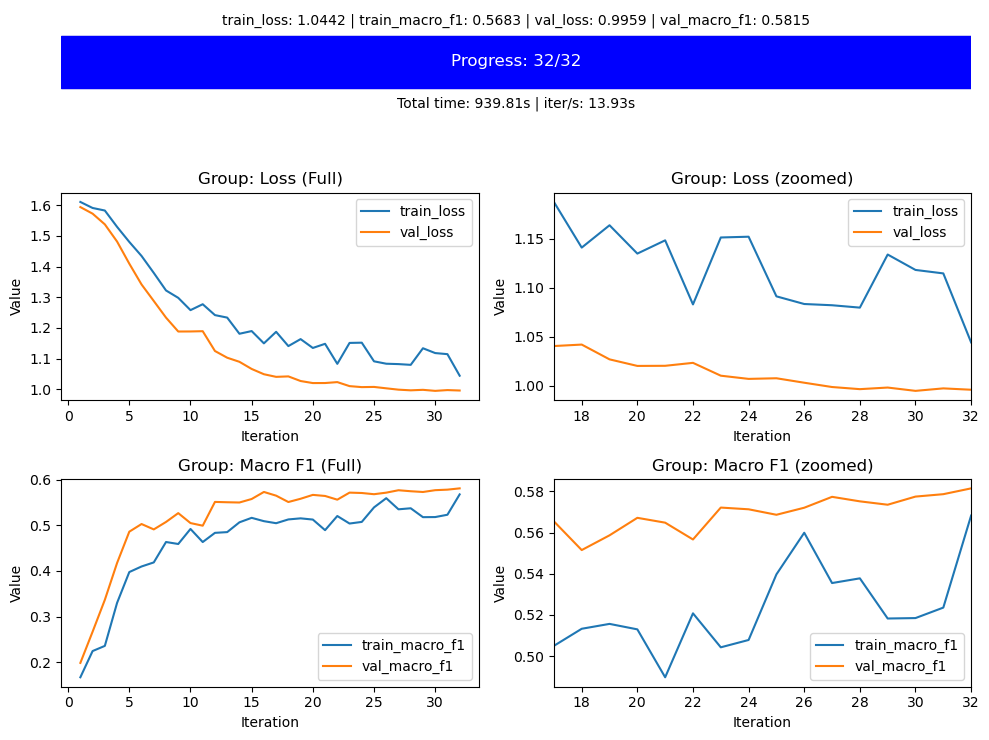

💾 Neues bestes Modell gespeichert (F1: 0.5815)
  Epoch 3/3 | Val Loss: 0.9959 | Val F1: 0.5815
Training fertig. Bester Val Macro-F1: 0.5815
Beste F1 nach Phase 1: 0.5815


In [16]:

from collections import Counter

counts = Counter(train_df["class_id"].values)
total = sum(counts.values())
weights = torch.tensor([total / (num_classes * counts[i]) for i in range(num_classes)], dtype=torch.float32).to(device)
print("Klassengewichte:", weights)

model = PigClassifier(num_classes=5, model_name=MODEL_NAME).to(device)

learner = Learner(
    model=model,
    train_dl=train_loader,
    val_dl=val_loader,
    loss_fn=nn.CrossEntropyLoss(weight=weights),
    eval_steps=20,
)

# Phase 1: nur den Klassifikationskopf trainieren
for p in model.parameters():
    p.requires_grad = False

for p in model.model.classifier.parameters():
    p.requires_grad = True
    
model = torch.nn.DataParallel(model, device_ids=[0,1,2,3])

best_state, best_f1 = learner.fit(epochs=3, lr=1e-3)
print(f"Beste F1 nach Phase 1: {best_f1:.4f}")


In [17]:
torch.save(model.state_dict(), "pig_classifier_checkpoint_5.0.pth")

In [18]:
learner.load_best()
torch.save(model.state_dict(), "pig_classifier_best_5.0.pth")

✅ Bestes Modell geladen (F1: 0.5815)


Classification Report (pro Klasse)
                     precision    recall  f1-score   support

 Lateral_lying_left     0.5657    0.6554    0.6073       624
Lateral_lying_right     0.5954    0.5954    0.5954       692
            Sitting     0.1480    0.5645    0.2345       124
           Standing     0.8850    0.7922    0.8360      1963
      Sternal_lying     0.7109    0.5727    0.6343      1245

           accuracy                         0.6796      4648
          macro avg     0.5810    0.6360    0.5815      4648
       weighted avg     0.7327    0.6796    0.6994      4648



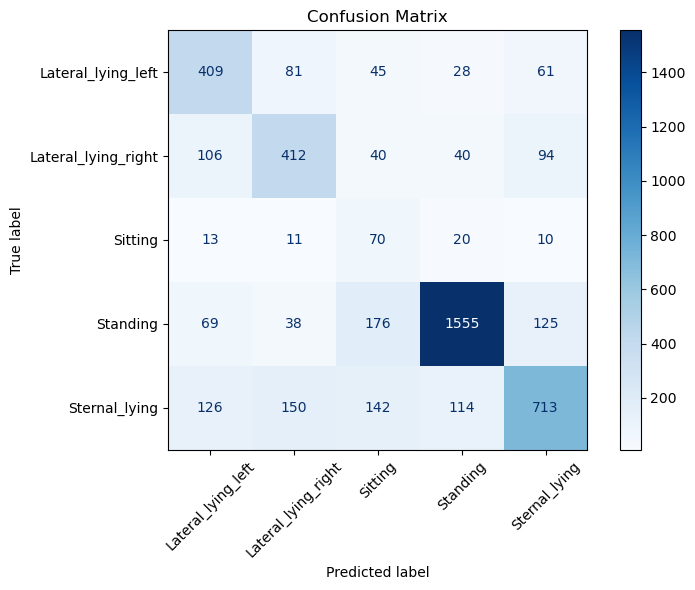

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def evaluate_per_class(model, dl, class_names, device=device):
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    for xb, yb in dl:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        all_preds.append(logits.argmax(dim=1).cpu())
        all_labels.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    print("=" * 60)
    print("Classification Report (pro Klasse)")
    print("=" * 60)
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        digits=4
    ))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
class_names = pig_posture_classes["class_name"].tolist()
evaluate_per_class(model, val_loader, class_names)

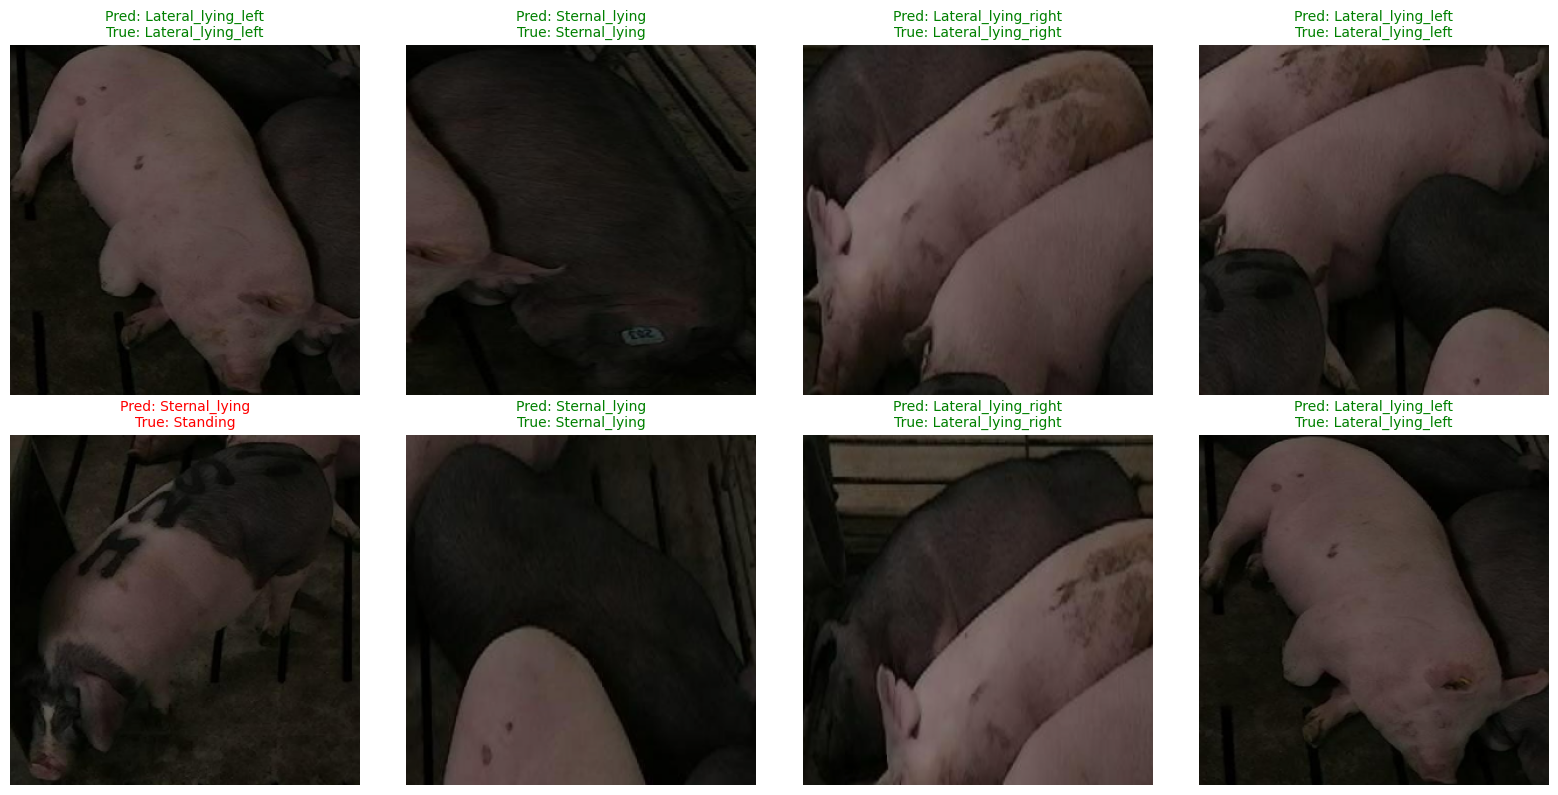

In [20]:
def show_predictions(model, dl, class_names, device=device, n=8):
    """Zeigt n Bilder mit predicted vs. true Klasse."""
    model.eval()
    model.to(device)

    imgs, labels = next(iter(dl))
    imgs_dev = imgs.to(device)

    with torch.no_grad():
        logits = model(imgs_dev)

    pred_labels = logits.argmax(dim=1).cpu().numpy()
    true_labels = labels.numpy()

    n = min(n, len(imgs))
    cols = max(n // 2, 1)
    fig, axes = plt.subplots(2, cols, figsize=(4 * cols, 8))
    axes = axes.flatten()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(n):
        img_np = imgs[i].permute(1, 2, 0).numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        ax = axes[i]
        ax.imshow(img_np)

        pred_name = class_names[pred_labels[i]]
        true_name = class_names[true_labels[i]]
        color = "green" if pred_labels[i] == true_labels[i] else "red"
        ax.set_title(f"Pred: {pred_name}\nTrue: {true_name}", color=color, fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

class_names = pig_posture_classes["class_name"].tolist()
show_predictions(model, val_loader, class_names)

In [21]:


learner.load_best()          # Bestes Modell aus Phase 1 laden
learner.unfreeze()
best_state, best_f1 = learner.fit(epochs=10, lr=1e-4)

✅ Bestes Modell geladen (F1: 0.5815)
✅ Alle Parameter freigegeben.
Training: 10 Epochs, 196 Batches/Epoch, 1960 Total Steps
LR=0.0001, WD=0.001, AMP=False, Device=cuda
Eval alle 20 Steps → ~106 Monitor-Updates


📚 Epochen:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/10:   0%|          | 0/196 [00:03<?, ?it/s]

RuntimeError: CUDA out of memory. Tried to allocate 396.00 MiB (GPU 0; 15.78 GiB total capacity; 13.90 GiB already allocated; 322.88 MiB free; 14.10 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [ ]:
torch.save(model.state_dict(), "pig_classifier_checkpoint_5.0.pth")

In [ ]:
learner.load_best()
torch.save(model.state_dict(), "pig_classifier_best_5.0.pth")

In [ ]:
# ── Laden ──
model = PigClassifier(num_classes=5, model_name=MODEL_NAME).to(device)
model.load_state_dict(torch.load("pig_classifier_best_5.0", map_location=device))

In [ ]:
# Predictions
cls_preds = learner.predict(test_loader)

In [ ]:
# Submission erstellen
submission = pd.DataFrame({
    "row_id":   test_df["row_id"],
    "class_id": cls_preds,
})
submission.head()

In [ ]:
submission.to_csv("submission_5.0.csv", index=False)

In [ ]:
submission.info()